In [2]:
import pydot
from IPython.display import Image, display, HTML
import queue
import numpy as np
import base64
import heapq
import yfinance
import pandas as pd
from typing import List, Tuple, Dict, Optional, Set
import seaborn as sns
import matplotlib.pyplot as plt

## Importación Datos

In [53]:
seguras = ['AAPL', 'MSFT', 'JNJ', 'PG', 'KO', 'PEP', 'V', 'MA', 'WMT', 'UNH']
medias = ['AMZN', 'GOOGL', 'META', 'NFLX', 'DIS', 'ADBE', 'INTC', 'ORCL', 'CSCO', 'NVDA']
riesgosas = ['TSLA', 'NIO', 'PLTR', 'SNAP', 'RIVN', 'COIN', 'SPCE', 'DKNG', 'HOOD', 'AMC']
TICKERS = seguras + medias + riesgosas
operators = list(TICKERS)

In [54]:
def obtener_metricas(tickers: List[str], period: str = "1y") -> Tuple[pd.Series, pd.Series]:
    data = yfinance.download(tickers, period=period, auto_adjust=False, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        precios = data.xs('Adj Close', axis=1, level=0)
    else:
        precios = data[['Adj Close']]

    retorno_diario = precios.pct_change().dropna()
    log_returns = np.log(precios / precios.shift(1)).dropna()

    media_diaria = retorno_diario.mean()
    std_diaria  = log_returns.std()
 
    return media_diaria * 250, std_diaria * np.sqrt(250)

In [55]:
retorno_esperado_anual, riesgo_individual_anual = obtener_metricas(TICKERS, period="1y")

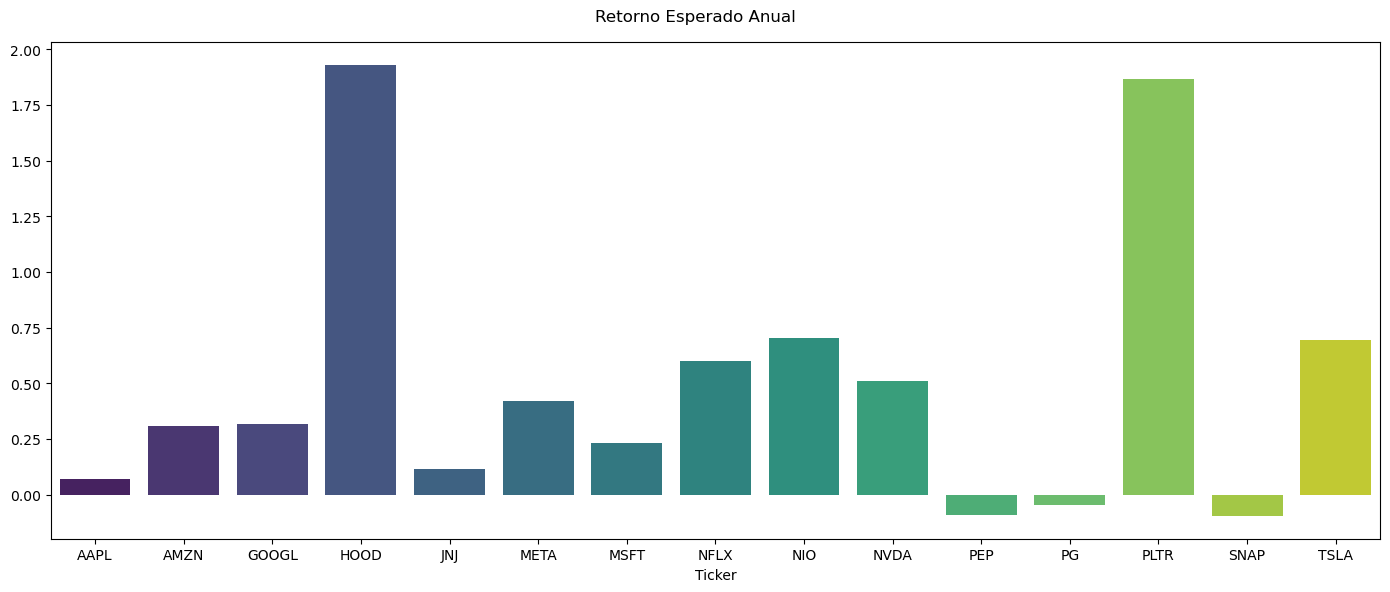

In [86]:
figure = plt.figure(figsize=(14, 6))
sns.barplot(x=retorno_esperado_anual.index, y=retorno_esperado_anual.values, palette='viridis', hue=retorno_esperado_anual.index)
figure.suptitle('Retorno Esperado Anual')
plt.tight_layout()
plt.show()

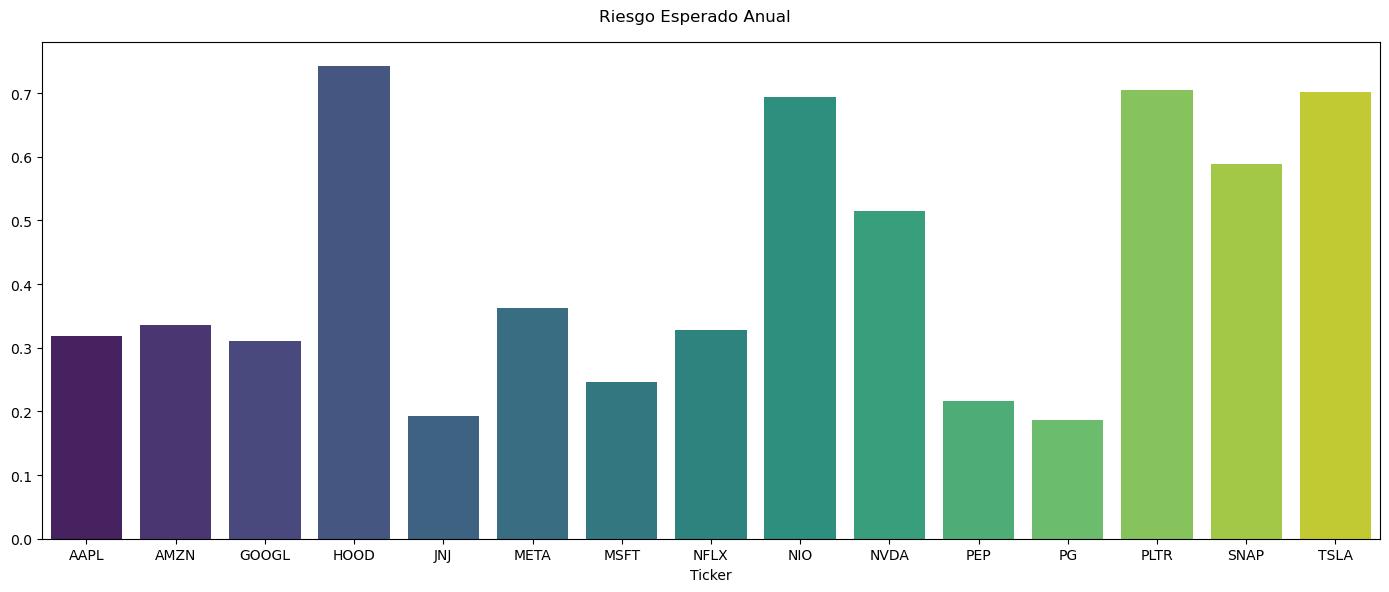

In [87]:
figure = plt.figure(figsize=(14, 6))
sns.barplot(x=riesgo_individual_anual.index, y=riesgo_individual_anual.values, palette='viridis', hue=riesgo_individual_anual.index)
figure.suptitle('Riesgo Esperado Anual')
plt.tight_layout()
plt.show()

## Función de Calidad

In [56]:
def evaluar_portafolio(acciones: List[str], retorno_esperado_anual: pd.Series, riesgo_individual_anual: pd.Series, pesos: Optional[np.ndarray] = None) -> Tuple[float, float]:
    k = len(acciones)
    if pesos is None:
        pesos = np.ones(k) / k
        
    mean = retorno_esperado_anual[acciones].values
    std = riesgo_individual_anual[acciones].values
    
    rendimiento = float(np.dot(mean, pesos))
    riesgo = float(np.dot(std, pesos))**2
    
    return rendimiento, riesgo

## Clase Nodo

In [6]:
class Node ():
    def __init__(self, state,value,operators, operator=None, parent=None,objective=None):
        self.state= state
        self.value = value
        self.children = []
        self.parent=parent
        self.operator=operator
        self.operators=operators
        self.objective=objective
        self.level=0

    def add_child(self, value, state, operator):
        node=type(self)(value=value, state=state, operator=operator,parent=self, operators=self.operators)
        node.level=node.parent.level+1
        self.children.append(node)
        return node

    def add_node_child(self, node):
        node.level=node.parent.level+1
        self.children.append(node)
        return node

    #Devuelve todos los estados según los operadores aplicados
    def getchildrens(self):
        return [
            self.getState(i)
            if not self.repeatStatePath(self.getState(i))
                else None for i, op in enumerate(operators)]
    
    def heuristic(self):
        value_1 = abs(endState[0] - self.state[0])
        value_2 = abs(endState[1] - self.state[1])
        return value_1 + value_2

    def getState(self, index):
        pass

    def __eq__(self, other):
        return self.state == other.state

    def __lt__(self, other):
        return self.f() < other.f()


    def repeatStatePath(self, state):
        n=self
        while n is not None and n.state!=state:
            n=n.parent
        return n is not None

    def pathObjective(self):
        n=self
        result=[]
        while n is not None:
            result.append(n)
            n=n.parent
        return result

    def printPath(self):
        stack=self.pathObjective()
        while len(stack)!=0:
            node=stack.pop()
            if node.operator is not None:
                print(f'operador:  {operators[node.operator]} \t estado: {node.state}')
            else:
                print(f' {node.state}')

    def cost(self):
        return 1

    def f(self):
        return self.cost()

## Gráfico

In [14]:
def draw(root,path):
    graph = pydot.Dot(graph_type='graph')
    nodeGraph=pydot.Node(str(root.state)+"-"+str(0),
                         label=str(root.state),shape ="circle",
                         style="filled", fillcolor="red")
    graph.add_node(nodeGraph)
    path.pop()
    return drawTreeRec(root,nodeGraph,graph,0,path.pop(),path)

def drawTreeRec(root,rootGraph,graph,i,topPath,path):
    if root is not None:
      children=root.children
      for j,child in enumerate(children):
        i=i+1
        color="white"
        if topPath.value==child.value:
          if len(path)>0:topPath=path.pop()
          color='red'
        c=pydot.Node(child.value,label=str(child.state)+r"\n"+r"\n"+"f="+str(child.f()),
                     shape ="circle", style="filled",
                     fillcolor=color)
        graph.add_node(c)
        graph.add_edge(pydot.Edge(rootGraph, c,
                                  label=str(child.operator)+'('+str(child.cost())+')'))
        graph=drawTreeRec(child,c,graph,i,topPath,path)
      return graph
    else:
      return graph

In [28]:
def get_solution_path(goal_node):
    """
    Retorna [root, ..., goal]. Si ya tienes goal_node.pathObjective(), lo usa.
    """
    if goal_node is None:
        return []
    if hasattr(goal_node, "pathObjective") and callable(goal_node.pathObjective):
        return goal_node.pathObjective()
    # genérico por punteros a parent
    path = []
    n = goal_node
    while n is not None:
        path.append(n)
        n = getattr(n, "parent", None)
    return list(reversed(path))

def _ticker_added(parent_state, child_state):
    """Detecta qué ticker se agregó al pasar de parent->child para etiquetar la arista."""
    ps, cs = set(parent_state), set(child_state)
    add = list(cs - ps)
    return add[0] if len(add) == 1 else None

def draw_portfolio_tree_uc(root, goal=None, filename="portfolio_uc.png",
                           fmt="png", depth_limit=None, show_f=False):
    """
    Dibuja el árbol ya construido desde `root` (tras correr UCS).
    - goal: nodo objetivo para resaltar la ruta solución de rojo
    - depth_limit: limita profundidad mostrada si el árbol es muy grande
    - show_f: si True muestra f(n)=g(n)+h(n); para UCS deja False y muestra g(n) (cost)
    """
    graph = pydot.Dot(graph_type="digraph", rankdir="TB",
                      labelloc="t", label="Árbol - Búsqueda por Costo Uniforme",
                      concentrate="false", splines="true")

    # Nodos de la ruta solución
    path_nodes = set(n.value for n in get_solution_path(goal)) if goal else set()

    # DFS iterativa para no depender de recursión
    stack = [root]
    seen = set()

    def add_node(n):
        node_id = str(n.value)
        if node_id in seen:
            return
        seen.add(node_id)
        # Etiqueta del nodo: estado + costo g(n) o f(n)
        g = n.cost()
        label = f"{list(n.state)}\\n" + (f"f={n.f():.6f}" if show_f else f"g={g:.6f}")
        color = "red" if node_id in path_nodes else "white"
        pydot_node = pydot.Node(node_id, label=label, shape="circle", style="filled",
                                fillcolor=color, fontsize="10")
        graph.add_node(pydot_node)

    while stack:
        node = stack.pop()
        add_node(node)

        # profundidad (si está disponible). Si no, no limitamos.
        lvl = getattr(node, "level", None)
        if depth_limit is not None and lvl is not None and lvl >= depth_limit:
            continue

        for child in getattr(node, "children", []):
            add_node(child)
            # Etiqueta de la arista: TICKER agregado + costo acumulado del hijo
            ticker = _ticker_added(node.state, child.state)
            edge_label = f"{ticker if ticker else child.operator} (g={child.cost():.6f})"
            graph.add_edge(pydot.Edge(str(node.value), str(child.value), label=edge_label, fontsize="9"))
            stack.append(child)

    # Guardar
    graph.write(filename, format=fmt)
    return filename

## Clase Portafolio

In [52]:
class PortfolioMap(Node):
    retorno: pd.Series = None
    riesgo: pd.Series = None
    K: int = 10
    objective: str = "max_retorno"
    costo_positivos: float = 0.0 # Asegurar costos no negativos

    def __init__(self, tickers=None, retorno=None, riesgo=None, k=None, objective=None, **kwargs):
        super(PortfolioMap, self).__init__(**kwargs)
        if retorno is not None:
            PortfolioMap.retorno = retorno
        if riesgo is not None:
            PortfolioMap.riesgo = riesgo
        if k is not None:
            PortfolioMap.K = int(k)
        if objective is not None:
            PortfolioMap.objective = str(objective)
        if tickers is not None and "operators" not in kwargs:
            self.operators = tuple(tickers)
        elif "operators" in kwargs and kwargs["operators"] is not None:
            self.operators = tuple(self.operators)
        if tickers is not None and retorno is not None:
            PortfolioMap.costo_positivos = float(PortfolioMap.retorno.loc[list(tickers)].max())

    def add_child(self, value, state, operator):
        next_ops = self.operators[operator+1:] if operator is not None else self.operators
        node = type(self)(value=value, state=state, operator=operator, parent=self,
                          operators=next_ops, objective=PortfolioMap.objective)
        node.level = node.parent.level + 1
        self.children.append(node)
        return node

    def getState(self, index):
        if index < 0 or index >= len(self.operators):
            return None
        t = self.operators[index]
        if t in self.state:
            return None
        restantes_despues = len(self.operators) - (index + 1)
        if restantes_despues < (PortfolioMap.K - (len(self.state) + 1)):
            return None
        return tuple(sorted(self.state + (t,)))

    def heuristic(self):
        restantes = list(self.operators) # Restantes después de la ejecución
        faltan = PortfolioMap.K - len(self.state) # Faltantes para completar el portafolio

        # Validación para que no se agreguen más acciones
        if faltan <= 0 or len(restantes) == 0:
            return 0.0

        if PortfolioMap.objective == "max_retorno":
            array = PortfolioMap.retorno.loc[restantes].values # Valores de retorno de los activos restantes
            faltantes = min(faltan, array.size) # Activos a considerar
            if faltantes <= 0:
                return 0.0
            indices = np.argpartition(array, array.size - faltantes)[array.size - faltantes:] # Índices de los activos a considerar
            return float(-(max(array[indices]))) # Se retorna en negativo porque se busca maximizar el retorno
        else:
            array = PortfolioMap.riesgo.loc[restantes].values # Valores de riesgo de los activos restantes
            faltantes = min(faltan, array.size) # Activos a considerar
            if faltantes <= 0:
                return 0.0
            indices = np.argpartition(array, faltantes - 1)[:faltantes] # Índices de los activos a considerar
            return float(array[indices].sum()) # Se retorna el riesgo total de los activos seleccionados

    def ticker_cost(self, t):
        if PortfolioMap.objective == "min_riesgo":
            return float(PortfolioMap.riesgo.loc[t]) # Se retorna el riesgo del activo
        else:
            return float(PortfolioMap.costo_positivos - PortfolioMap.retorno.loc[t]) # Se retorna el rendimiento del activo

    def cost(self):
        # Cálculo del costo total del portafolio con los activos seleccionados
        return 0.0 if not self.state else float(sum(self.ticker_cost(t) for t in self.state))

    def f(self):
        return self.cost() + self.heuristic()

## Best-First

In [8]:
import queue

def bestFirst(root):
    pq = queue.PriorityQueue()
    pq.put((root.heuristic(), root))
    while not pq.empty():
        node = pq.get()[1]
        children = node.getchildrens()
        for i, child in enumerate(children):
            if child is not None:
                newChild = node.add_child(
                    value=node.value + '-' + str(i),
                    state=child,
                    operator=i
                )
                pq.put((newChild.heuristic(), newChild))
                if len(newChild.state) == PortfolioMap.K:
                    return (root, newChild)
    return (root, None)


In [17]:
K = 5
objetivo = "max_retorno"
# objetivo = "min_riesgo"
root = PortfolioMap(tickers=TICKERS, retorno=retorno_esperado_anual, riesgo=riesgo_individual_anual, k=K, objective=objetivo, value="root", state=tuple(), operators=TICKERS)

tree, objective_node = bestFirst(root)

path = objective_node.pathObjective()
objective_node.printPath()

acciones = list(objective_node.state)
rend, risk = evaluar_portafolio(acciones, retorno_esperado_anual, riesgo_individual_anual)

print("== Best-First ==")
print("Acciones:", acciones)
print(f"Rendimiento: {rend:.6f} | Riesgo: {risk:.6f}")

 ()
operador:  TSLA 	 estado: ('TSLA',)
operador:  AAPL 	 estado: ('NIO', 'TSLA')
operador:  AAPL 	 estado: ('NIO', 'PLTR', 'TSLA')
operador:  JNJ 	 estado: ('COIN', 'NIO', 'PLTR', 'TSLA')
operador:  AAPL 	 estado: ('COIN', 'NIO', 'PLTR', 'SPCE', 'TSLA')
== Best-First ==
Acciones: ['COIN', 'NIO', 'PLTR', 'SPCE', 'TSLA']
Rendimiento: 0.784426 | Riesgo: 0.572972


## Costo Uniforme

In [51]:
from itertools import count
import heapq as hq

def uniformCost(root, startState=None, endState=None):
    seq = count() # contador para desempate
    root.level = getattr(root, "level", 0) # nivel del nodo raíz
    pq = []
    hq.heappush(pq, (root.cost(), next(seq), root))
    while pq:
        g, _, node = hq.heappop(pq)
        if len(node.state) == PortfolioMap.K:
            return (root, node)
        children = node.getchildrens()
        for i, child_state in enumerate(children):
            if child_state is not None:
                newChild = node.add_child(
                    value=f"{node.value}-{i}",
                    state=child_state,
                    operator=i
                )
                newChild.level = getattr(node, "level", 0) + 1
                hq.heappush(pq, (newChild.cost(), next(seq), newChild))

    return (root, None)

In [57]:
K = 10
objetivo = "max_retorno"
# objetivo = "min_riesgo"
root = PortfolioMap(tickers=TICKERS, retorno=retorno_esperado_anual, riesgo=riesgo_individual_anual, k=K, objective=objetivo, value="root", state=tuple(), operators=TICKERS)
    
tree, objective_node = uniformCost(root)

# Imprimir ruta y métricas (tu código)
path = get_solution_path(objective_node)
acciones = list(objective_node.state)
rend, risk = evaluar_portafolio(acciones, retorno_esperado_anual, riesgo_individual_anual)
print("Acciones:", acciones)
print(f"Rend: {rend:.6f} | Riesgo: {risk:.6f}")

# Graficar (resalta en rojo la ruta solución)
# outfile = draw_portfolio_tree_uc(tree, goal=objective_node,
#                                  filename="portfolio_uniform_cost.pdf",  # PDF se ve mejor en árboles grandes
#                                  fmt="pdf",
#                                  depth_limit=None,   # por si necesitas recortar
#                                  show_f=False)       # UCS: mostramos g(n)
# print("Árbol guardado en:", outfile)


Acciones: ['COIN', 'DKNG', 'HOOD', 'META', 'NFLX', 'NIO', 'NVDA', 'ORCL', 'PLTR', 'TSLA']
Rend: 0.886359 | Riesgo: 0.331930
